**Setup and Imports**

In [1]:
# Cell 1: Setup and imports
import os
import numpy as np
import pandas as pd
import torch
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Paths (same as before)
BASE_PATH = "/content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison"
PREPROCESSED_PATH = os.path.join(BASE_PATH, "preprocessed_dataset")
RESULTS_PATH = os.path.join(BASE_PATH, "results")

# Create results folder if needed
os.makedirs(RESULTS_PATH, exist_ok=True)

print(f"Preprocessed path: {PREPROCESSED_PATH}")
print(f"Results path: {RESULTS_PATH}")

Preprocessed path: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/preprocessed_dataset
Results path: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results


**Load Binary Data**

In [2]:
# Cell 2: Load binary datasets
train_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_train_binary.csv"))
val_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_val_binary.csv"))
test_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))

# Ensure correct column names
train_df = train_df.rename(columns={"text": "text", "label": "label"})
val_df = val_df.rename(columns={"text": "text", "label": "label"})
test_df = test_df.rename(columns={"text": "text", "label": "label"})

train_df["text"] = train_df["text"].astype(str)
val_df["text"] = val_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Val  :", val_df.shape, val_df["label"].value_counts().to_dict())
print("Test :", test_df.shape, test_df["label"].value_counts().to_dict())

Train: (105882, 2) {1: 99110, 0: 6772}
Val  : (15126, 2) {1: 14159, 0: 967}
Test : (30253, 2) {1: 28318, 0: 1935}


**Zero-Shot Evaluation (Bangla-BERT)**

In [3]:
# Cell 3: Zero-shot evaluation with Bangla-BERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding

MODEL_NAME = "sagorsarker/bangla-bert-base"
MAX_LEN = 128

print("="*60)
print("ZERO-SHOT EVALUATION - BanglaBook with Bangla-BERT")
print("="*60)

# Load binary test set
test_df_zero = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))
test_df_zero = test_df_zero.rename(columns={"text": "text", "label": "label"})
test_df_zero["text"] = test_df_zero["text"].astype(str)
test_df_zero["label"] = test_df_zero["label"].astype(int)

# Create HF dataset
test_ds = Dataset.from_pandas(test_df_zero[["text", "label"]])

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

test_ds = test_ds.map(tok, batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load model (2-class for binary)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Predict
trainer = Trainer(model=model, data_collator=collator)
pred = trainer.predict(test_ds)

logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = test_df_zero["label"].values

# Metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print(f"\nTest samples: {len(test_df_zero)}")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"F1-score: {f1:.4f} ({f1*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall: {recall:.4f} ({recall*100:.2f}%)")
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)

# Save zero-shot results
with open(os.path.join(RESULTS_PATH, "banglabook_banglabert_zero_shot.txt"), "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("DATASET: BanglaBook (binary: 0=NEG, 1=POS)\n")
    f.write("EVALUATION: Zero-shot\n\n")
    f.write(f"Test samples: {len(test_df_zero)}\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n\n")
    f.write("Confusion Matrix [ [TN FP], [FN TP] ]:\n")
    f.write(str(cm) + "\n")

print(f"\nResults saved to: {RESULTS_PATH}/banglabook_banglabert_zero_shot.txt")

ZERO-SHOT EVALUATION - BanglaBook with Bangla-BERT


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/30253 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Test samples: 30253
Accuracy: 0.8716 (87.16%)
F1-score: 0.9308 (93.08%)
Precision: 0.9398 (93.98%)
Recall: 0.9219 (92.19%)

Confusion Matrix [ [TN FP], [FN TP] ]:
[[  264  1671]
 [ 2213 26105]]

Results saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabook_banglabert_zero_shot.txt


**Zero-Shot Confusion Matrix Visualization**

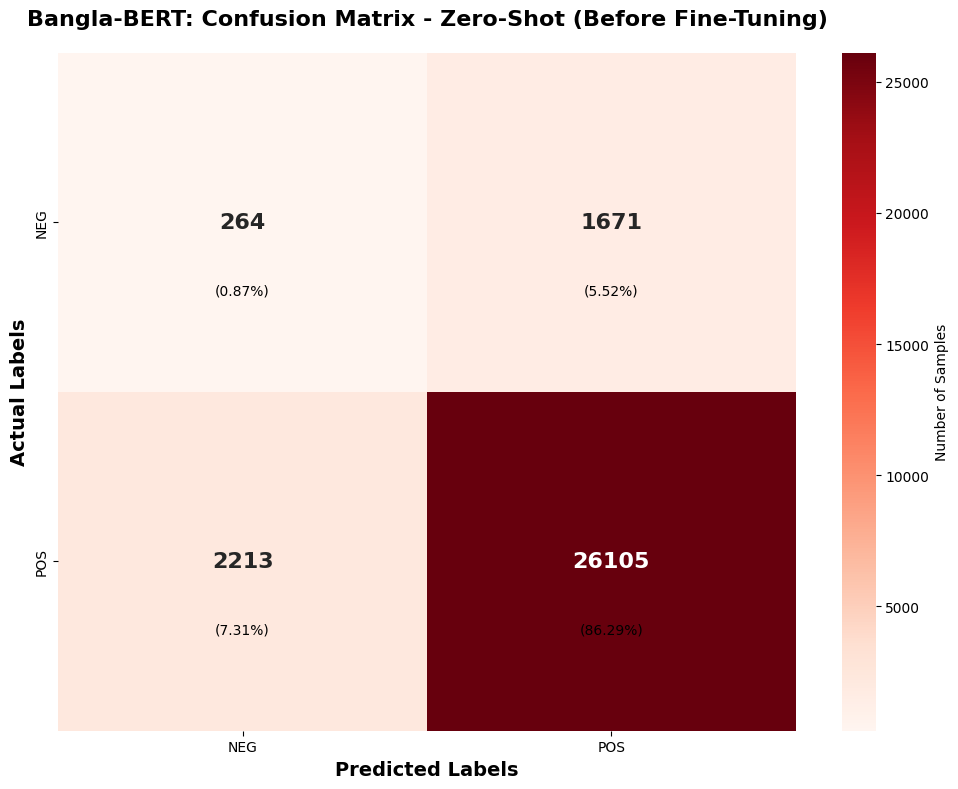

Zero-shot confusion matrix saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabert_confusion_matrix_zero_shot.png


In [4]:
# Cell 4: Zero-shot confusion matrix visualization (Fixed - No Overlap)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))

# Create heatmap
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                  xticklabels=['NEG', 'POS'],
                  yticklabels=['NEG', 'POS'],
                  annot_kws={'size': 16, 'weight': 'bold'},
                  cbar_kws={'label': 'Number of Samples'})

# Add percentages with proper positioning
total = np.sum(cm)
for i in range(2):
    for j in range(2):
        value = cm[i, j]
        percentage = (value / total) * 100
        # Add percentage text below the number
        ax.text(j + 0.5, i + 0.7, f'({percentage:.2f}%)',
                ha='center', va='center', fontsize=10, color='black', weight='normal')

plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('Actual Labels', fontsize=14, fontweight='bold')
plt.title('Bangla-BERT: Confusion Matrix - Zero-Shot (Before Fine-Tuning)',
          fontsize=16, fontweight='bold', pad=20)

# Adjust layout to prevent cutoff
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "banglabert_confusion_matrix_zero_shot.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Zero-shot confusion matrix saved to: {RESULTS_PATH}/banglabert_confusion_matrix_zero_shot.png")

**Fine-Tune Bangla-BERT**

In [5]:
# Cell 5: Fine-tune Bangla-BERT on BanglaBook
MODEL_NAME = "sagorsarker/bangla-bert-base"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42

set_seed(SEED)

print("="*60)
print("FINE-TUNING Bangla-BERT on BanglaBook")
print("="*60)

# Load binary datasets
train_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_train_binary.csv"))
val_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_val_binary.csv"))
test_df = pd.read_csv(os.path.join(PREPROCESSED_PATH, "BanglaBook_test_binary.csv"))

# Ensure correct column names
train_df = train_df.rename(columns={"text": "text", "label": "label"})
val_df = val_df.rename(columns={"text": "text", "label": "label"})
test_df = test_df.rename(columns={"text": "text", "label": "label"})

train_df["text"] = train_df["text"].astype(str)
val_df["text"] = val_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

# Convert to HF Dataset
train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tok, batched=True)
val_ds = val_ds.map(tok, batched=True)
test_ds = test_ds.map(tok, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load model for binary classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

# Training arguments
output_dir = os.path.join(RESULTS_PATH, "banglabert_banglabook_finetuned")
log_dir = os.path.join(RESULTS_PATH, "logs")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=SEED,
    logging_steps=50,
    logging_dir=log_dir,
    report_to="none",
    save_total_limit=2,
    greater_is_better=True
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# Train
print("\nStarting training...")
trainer.train()

# Save training history
history = trainer.state.log_history
history_file = os.path.join(RESULTS_PATH, "banglabert_training_history.json")
with open(history_file, "w") as f:
    json.dump(history, f, indent=2)
print(f"\nTraining history saved to: {history_file}")

FINE-TUNING Bangla-BERT on BanglaBook


Map:   0%|          | 0/105882 [00:00<?, ? examples/s]

Map:   0%|          | 0/15126 [00:00<?, ? examples/s]

Map:   0%|          | 0/30253 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training history saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabert_training_history.json


**Evaluate Fine-Tuned Bangla-BERT**

In [6]:
# Cell 6: Evaluate fine-tuned Bangla-BERT
print("\n" + "="*60)
print("EVALUATING FINE-TUNED Bangla-BERT ON TEST SET")
print("="*60)

pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = test_df["label"].values

# Metrics
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=["NEG", "POS"])

tn, fp, fn, tp = cm.ravel()

print(f"\nTest samples: {len(test_df)}")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score: {f1:.4f} ({f1*100:.2f}%)")
print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)
print("\nPer-class breakdown:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nClassification Report:")
print(report)

# Save results
with open(os.path.join(RESULTS_PATH, "banglabook_banglabert_fine_tuned.txt"), "w", encoding="utf-8") as f:
    f.write(f"MODEL: {MODEL_NAME}\n")
    f.write("DATASET: BanglaBook (binary: 0=NEG, 1=POS)\n")
    f.write("EVALUATION: Fine-tuned\n")
    f.write(f"Max_len={MAX_LEN}, Batch={BATCH_SIZE}, Epochs={EPOCHS}, LR={LR}, Seed={SEED}\n\n")
    f.write(f"Test samples: {len(test_df)}\n\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1-score: {f1:.4f}\n\n")
    f.write("Confusion Matrix [ [TN FP], [FN TP] ]:\n")
    f.write(str(cm) + "\n\n")
    f.write("Per-class breakdown:\n")
    f.write(f"True Negatives (TN): {tn}\n")
    f.write(f"False Positives (FP): {fp}\n")
    f.write(f"False Negatives (FN): {fn}\n")
    f.write(f"True Positives (TP): {tp}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"\nResults saved to: {RESULTS_PATH}/banglabook_banglabert_fine_tuned.txt")


EVALUATING FINE-TUNED Bangla-BERT ON TEST SET



Test samples: 30253
Accuracy: 0.9661 (96.61%)
Precision: 0.9699 (96.99%)
Recall: 0.9946 (99.46%)
F1-score: 0.9821 (98.21%)

Confusion Matrix [ [TN FP], [FN TP] ]:
[[ 1061   874]
 [  153 28165]]

Per-class breakdown:
True Negatives (TN): 1061
False Positives (FP): 874
False Negatives (FN): 153
True Positives (TP): 28165

Classification Report:
              precision    recall  f1-score   support

         NEG       0.87      0.55      0.67      1935
         POS       0.97      0.99      0.98     28318

    accuracy                           0.97     30253
   macro avg       0.92      0.77      0.83     30253
weighted avg       0.96      0.97      0.96     30253


Results saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabook_banglabert_fine_tuned.txt


**Fine-Tuned Confusion Matrix Visualization**

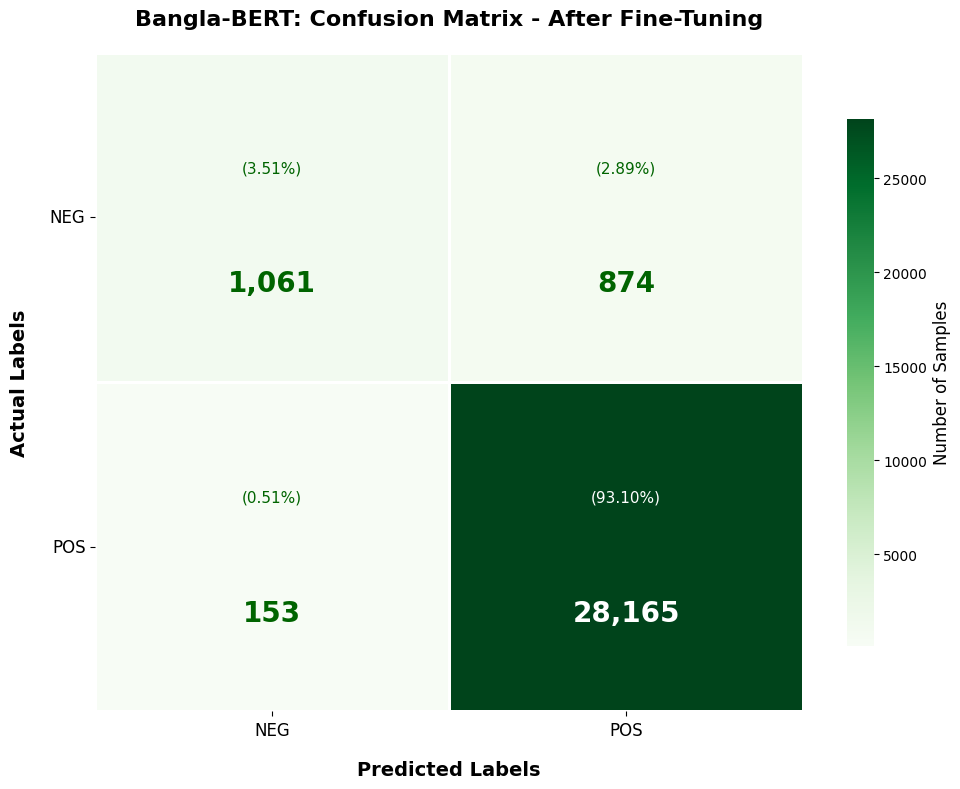


Fine-tuned confusion matrix saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabert_confusion_matrix_finetuned.png

Confusion Matrix Values:
  True Negatives (TN): 1,061
  False Positives (FP): 874
  False Negatives (FN): 153
  True Positives (TP): 28,165


In [7]:
# Cell 7: Fine-tuned confusion matrix visualization (Fixed - No Overlap)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))

# Create heatmap without automatic annotations
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='Greens',
                  xticklabels=['NEG', 'POS'],
                  yticklabels=['NEG', 'POS'],
                  cbar_kws={'label': 'Number of Samples', 'shrink': 0.8},
                  linewidths=2,
                  linecolor='white')

# Add annotations manually with proper positioning
total = np.sum(cm)
for i in range(2):
    for j in range(2):
        value = cm[i, j]
        percentage = (value / total) * 100

        # Main number (large, at top)
        ax.text(j + 0.5, i + 0.70, f'{value:,}',
                ha='center', va='center', fontsize=20, fontweight='bold',
                color='white' if value > total/4 else 'darkgreen')

        # Percentage (smaller, below the number)
        ax.text(j + 0.5, i + 0.35, f'({percentage:.2f}%)',
                ha='center', va='center', fontsize=11,
                color='white' if value > total/4 else 'darkgreen')

# Set labels
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Actual Labels', fontsize=14, fontweight='bold', labelpad=15)
plt.title('Bangla-BERT: Confusion Matrix - After Fine-Tuning',
          fontsize=16, fontweight='bold', pad=20)

# Adjust tick labels
ax.set_xticklabels(['NEG', 'POS'], fontsize=12, rotation=0)
ax.set_yticklabels(['NEG', 'POS'], fontsize=12, rotation=0)

# Adjust colorbar
cbar = ax.collections[0].colorbar
cbar.set_label('Number of Samples', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "banglabert_confusion_matrix_finetuned.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFine-tuned confusion matrix saved to: {RESULTS_PATH}/banglabert_confusion_matrix_finetuned.png")
print(f"\nConfusion Matrix Values:")
print(f"  True Negatives (TN): {cm[0,0]:,}")
print(f"  False Positives (FP): {cm[0,1]:,}")
print(f"  False Negatives (FN): {cm[1,0]:,}")
print(f"  True Positives (TP): {cm[1,1]:,}")

**Training Convergence Plot**

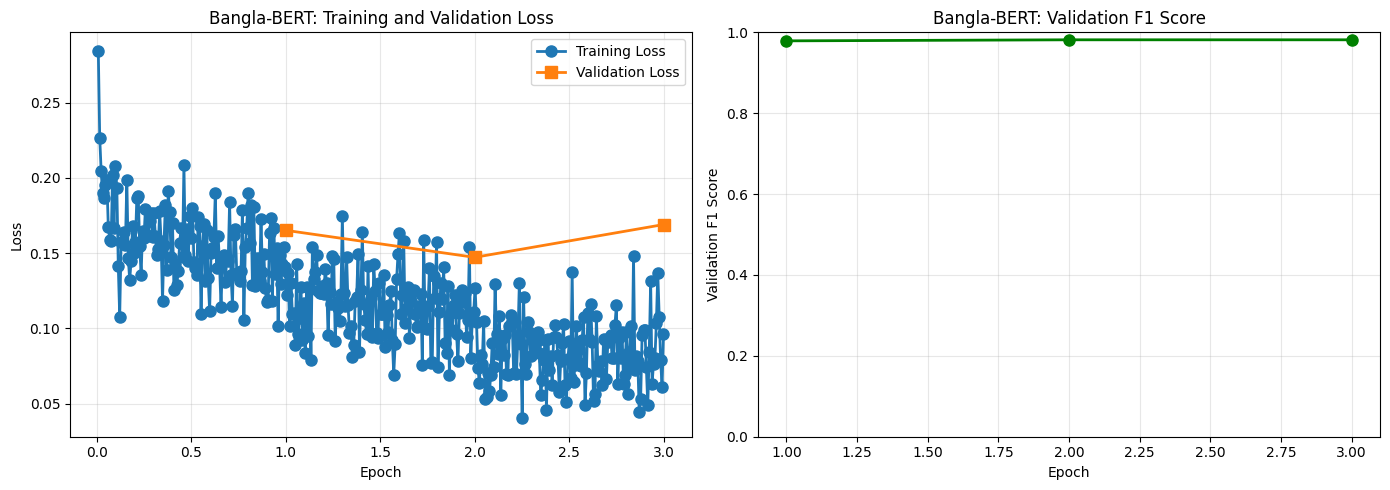

Convergence plot saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/banglabert_convergence.png


In [9]:
# Cell 8: Training convergence plot
history_file = os.path.join(RESULTS_PATH, "banglabert_training_history.json")

if os.path.exists(history_file):
    with open(history_file, 'r') as f:
        history = json.load(f)

    # Extract metrics
    epochs = []
    train_loss = []
    eval_loss = []
    eval_f1 = []

    for entry in history:
        if 'loss' in entry and 'epoch' in entry:
            train_loss.append(entry['loss'])
            epochs.append(entry['epoch'])
        if 'eval_loss' in entry:
            eval_loss.append(entry['eval_loss'])
        if 'eval_f1' in entry:
            eval_f1.append(entry['eval_f1'])

    # Remove duplicates for train loss
    unique_epochs = []
    unique_train_loss = []
    seen = set()
    for epoch, loss in zip(epochs, train_loss):
        if epoch not in seen:
            seen.add(epoch)
            unique_epochs.append(epoch)
            unique_train_loss.append(loss)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    if len(unique_epochs) > 0:
        axes[0].plot(unique_epochs, unique_train_loss, 'o-', label='Training Loss', linewidth=2, markersize=8)
    if len(eval_loss) > 0:
        eval_epochs = list(range(1, len(eval_loss) + 1))
        axes[0].plot(eval_epochs, eval_loss, 's-', label='Validation Loss', linewidth=2, markersize=8)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Bangla-BERT: Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # F1 plot
    if len(eval_f1) > 0:
        eval_epochs = list(range(1, len(eval_f1) + 1))
        axes[1].plot(eval_epochs, eval_f1, 'o-', color='green', linewidth=2, markersize=8)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Validation F1 Score')
        axes[1].set_title('Bangla-BERT: Validation F1 Score')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, "banglabert_convergence.png"), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Convergence plot saved to: {RESULTS_PATH}/banglabert_convergence.png")
else:
    print("Training history not found.")

**Comparison Table (Bangla-BERT vs XLM-RoBERTa)**

In [10]:
# Cell 9: Comparison with XLM-RoBERTa results
print("\n" + "="*70)
print("COMPARISON: Bangla-BERT vs XLM-RoBERTa on BanglaBook")
print("="*70)

# XLM-RoBERTa results (from your previous run)
xlm_results = {
    'Accuracy': 0.9680,
    'F1-Score': 0.9831,
    'Precision': 0.9733,
    'Recall': 0.9930,
    'Neg_F1': 0.706,
    'Pos_F1': 0.983
}

# Bangla-BERT results
banglabert_results = {
    'Accuracy': acc,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall,
    'Neg_F1': f1_score(y_true, y_pred, average=None)[0],
    'Pos_F1': f1_score(y_true, y_pred, average=None)[1]
}

print(f"\n{'Metric':<15} {'XLM-RoBERTa':<15} {'Bangla-BERT':<15} {'Difference':<15}")
print("-"*60)
for metric in ['Accuracy', 'F1-Score', 'Precision', 'Recall']:
    diff = xlm_results[metric] - banglabert_results[metric]
    print(f"{metric:<15} {xlm_results[metric]:<15.4f} {banglabert_results[metric]:<15.4f} {diff:+.4f}")

print("\nPer-class F1:")
print(f"  Negative: XLM-RoBERTa={xlm_results['Neg_F1']:.4f}, Bangla-BERT={banglabert_results['Neg_F1']:.4f}, Diff={xlm_results['Neg_F1'] - banglabert_results['Neg_F1']:+.4f}")
print(f"  Positive: XLM-RoBERTa={xlm_results['Pos_F1']:.4f}, Bangla-BERT={banglabert_results['Pos_F1']:.4f}, Diff={xlm_results['Pos_F1'] - banglabert_results['Pos_F1']:+.4f}")

# Save comparison
with open(os.path.join(RESULTS_PATH, "model_comparison.txt"), "w", encoding="utf-8") as f:
    f.write("COMPARISON: Bangla-BERT vs XLM-RoBERTa on BanglaBook\n")
    f.write("="*60 + "\n\n")
    f.write(f"XLM-RoBERTa Accuracy: {xlm_results['Accuracy']:.4f}\n")
    f.write(f"Bangla-BERT Accuracy: {banglabert_results['Accuracy']:.4f}\n")
    f.write(f"Difference: {xlm_results['Accuracy'] - banglabert_results['Accuracy']:+.4f}\n\n")
    f.write(f"XLM-RoBERTa F1: {xlm_results['F1-Score']:.4f}\n")
    f.write(f"Bangla-BERT F1: {banglabert_results['F1-Score']:.4f}\n")
    f.write(f"Difference: {xlm_results['F1-Score'] - banglabert_results['F1-Score']:+.4f}\n")

print(f"\nComparison saved to: {RESULTS_PATH}/model_comparison.txt")


COMPARISON: Bangla-BERT vs XLM-RoBERTa on BanglaBook

Metric          XLM-RoBERTa     Bangla-BERT     Difference     
------------------------------------------------------------
Accuracy        0.9680          0.9661          +0.0019
F1-Score        0.9831          0.9821          +0.0010
Precision       0.9733          0.9699          +0.0034
Recall          0.9930          0.9946          -0.0016

Per-class F1:
  Negative: XLM-RoBERTa=0.7060, Bangla-BERT=0.6739, Diff=+0.0321
  Positive: XLM-RoBERTa=0.9830, Bangla-BERT=0.9821, Diff=+0.0009

Comparison saved to: /content/drive/MyDrive/XMLROBERT/Dataset_Dimension_Comparison/results/model_comparison.txt


**Performance Metrics Table**